# Who Wins the Nobel Prize?

120+ years of laureates, and how unevenly the prize has been shared between men and women, and between categories. This notebook pulls every laureate from the official **Nobel Prize API** and looks at the share of prizes going to women, over time and by category.

Data source: https://api.nobelprize.org — public, no API key required.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import requests

API = "https://api.nobelprize.org/2.1/laureates"
HEADERS = {"User-Agent": "Mozilla/5.0"}

response = requests.get(API, params={"limit": 1100}, headers=HEADERS, timeout=30)
response.raise_for_status()
laureates = response.json()["laureates"]

rows = []
for laureate in laureates:
    gender = laureate.get("gender")
    if gender not in ("male", "female"):
        continue  # skip organisations (Red Cross, UN agencies, ...)
    for prize in laureate.get("nobelPrizes", []):
        rows.append({
            "year": int(prize["awardYear"]),
            "category": prize["category"]["en"],
            "gender": gender,
        })

df = pd.DataFrame(rows)
df["decade"] = (df["year"] // 10) * 10
df.tail()

,year,category,gender,decade
990,2008,Physics,male,2000
991,2016,Physiology or Medicine,male,2010
992,1986,Chemistry,male,1980
993,2005,Chemistry,male,2000
994,2000,Physics,male,2000


## Share of women, over time and by category

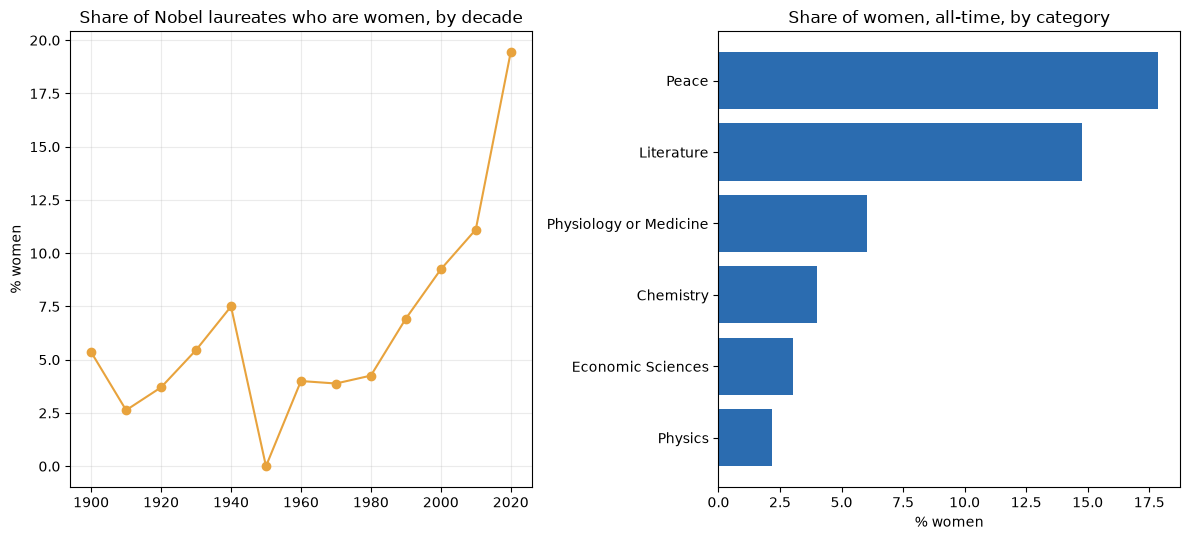

In [2]:
by_decade = df.groupby("decade")["gender"].apply(lambda s: (s == "female").mean() * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

ax1.plot(by_decade.index, by_decade.values, marker="o", color="#e8a33d")
ax1.set_title("Share of Nobel laureates who are women, by decade")
ax1.set_ylabel("% women")
ax1.grid(alpha=0.25)

by_category = df.groupby("category")["gender"].apply(lambda s: (s == "female").mean() * 100).sort_values()
ax2.barh(by_category.index, by_category.values, color="#2b6cb0")
ax2.set_title("Share of women, all-time, by category")
ax2.set_xlabel("% women")

fig.tight_layout()
plt.show()

## The headline numbers

In [3]:
print(f"Total laureates analysed: {len(df)}")
print(f"Overall share of women: {(df['gender'] == 'female').mean() * 100:.1f}%")
print(f"Most recent decade ({by_decade.index[-1]}s): {by_decade.iloc[-1]:.1f}% women")

Total laureates analysed: 995
Overall share of women: 6.8%
Most recent decade (2020s): 19.4% women
